In [1]:
pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install scipy>=1.12.0 --upgrade -v

In [3]:
!pip install psutil

Defaulting to user installation because normal site-packages is not writeable


In [4]:
!pip install numpy==1.24.3

Defaulting to user installation because normal site-packages is not writeable


In [5]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


2025-08-06 01:46:34.603867: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754444794.613027   69019 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754444794.617405   69019 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1754444794.622650   69019 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1754444794.622661   69019 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1754444794.622662   69019 computation_placer.cc:177] computation placer alr

ACTIVATION COMPARISON - NESTED SQUARES (2 NEURONS ONLY)

Experiment Configuration:
  Architecture: 2 neurons (single hidden layer)
  Initial tau (LASA): 1.6
  Outer square: 4.0x4.0
  Inner square: 2.0x2.0
  Epochs: 100
  Batch size: 32

Generating Nested Squares dataset...

Dataset info:
  Total samples: 712
  Training samples: 569
  Test samples: 143
  Class balance: 356 outer, 356 inner
  Challenge: Create box boundary with only 2 neurons!


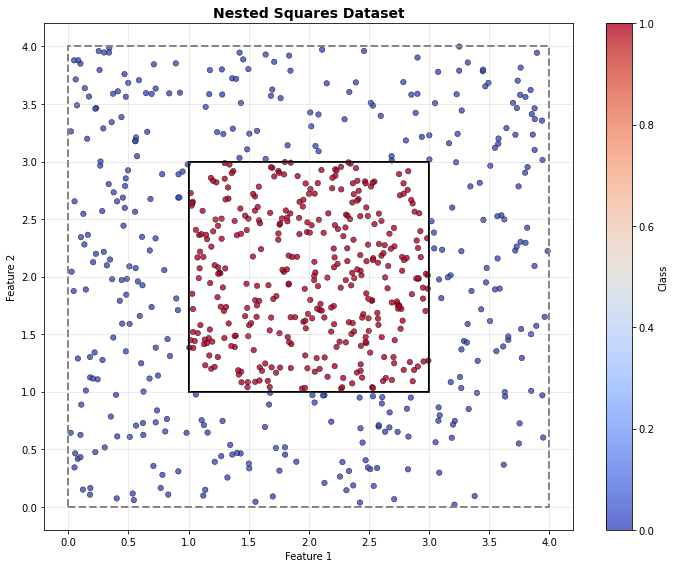


Training models with different activations...

LASA activation:
------------------------------


I0000 00:00:1754444797.040868   69019 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 93646 MB memory:  -> device: 0, name: NVIDIA GH200 480GB, pci bus id: 0000:dd:00.0, compute capability: 9.0


Model architecture:
  Input: 2 features
  Hidden: 2 neurons with lasa activation
  Output: 1 neuron with sigmoid
  Total parameters: 10

Final tau: 2.1134
Final Accuracy: 0.9650
Final Loss: 0.1038

RELU activation:
------------------------------
Final Accuracy: 0.6294
Final Loss: 0.5781

LEAKY_RELU activation:
------------------------------
Final Accuracy: 0.8601
Final Loss: 0.5080

ELU activation:
------------------------------
Final Accuracy: 0.7552
Final Loss: 0.5158

SOFTPLUS activation:
------------------------------
Final Accuracy: 0.7343
Final Loss: 0.4726

SWISH activation:
------------------------------
Final Accuracy: 0.7273
Final Loss: 0.5974

MISH activation:
------------------------------
Final Accuracy: 0.8322
Final Loss: 0.5639

GELU activation:
------------------------------
Final Accuracy: 0.5734
Final Loss: 0.6903

SIGMOID activation:
------------------------------
Final Accuracy: 0.8042
Final Loss: 0.4539

TANH activation:
------------------------------
Final Accurac

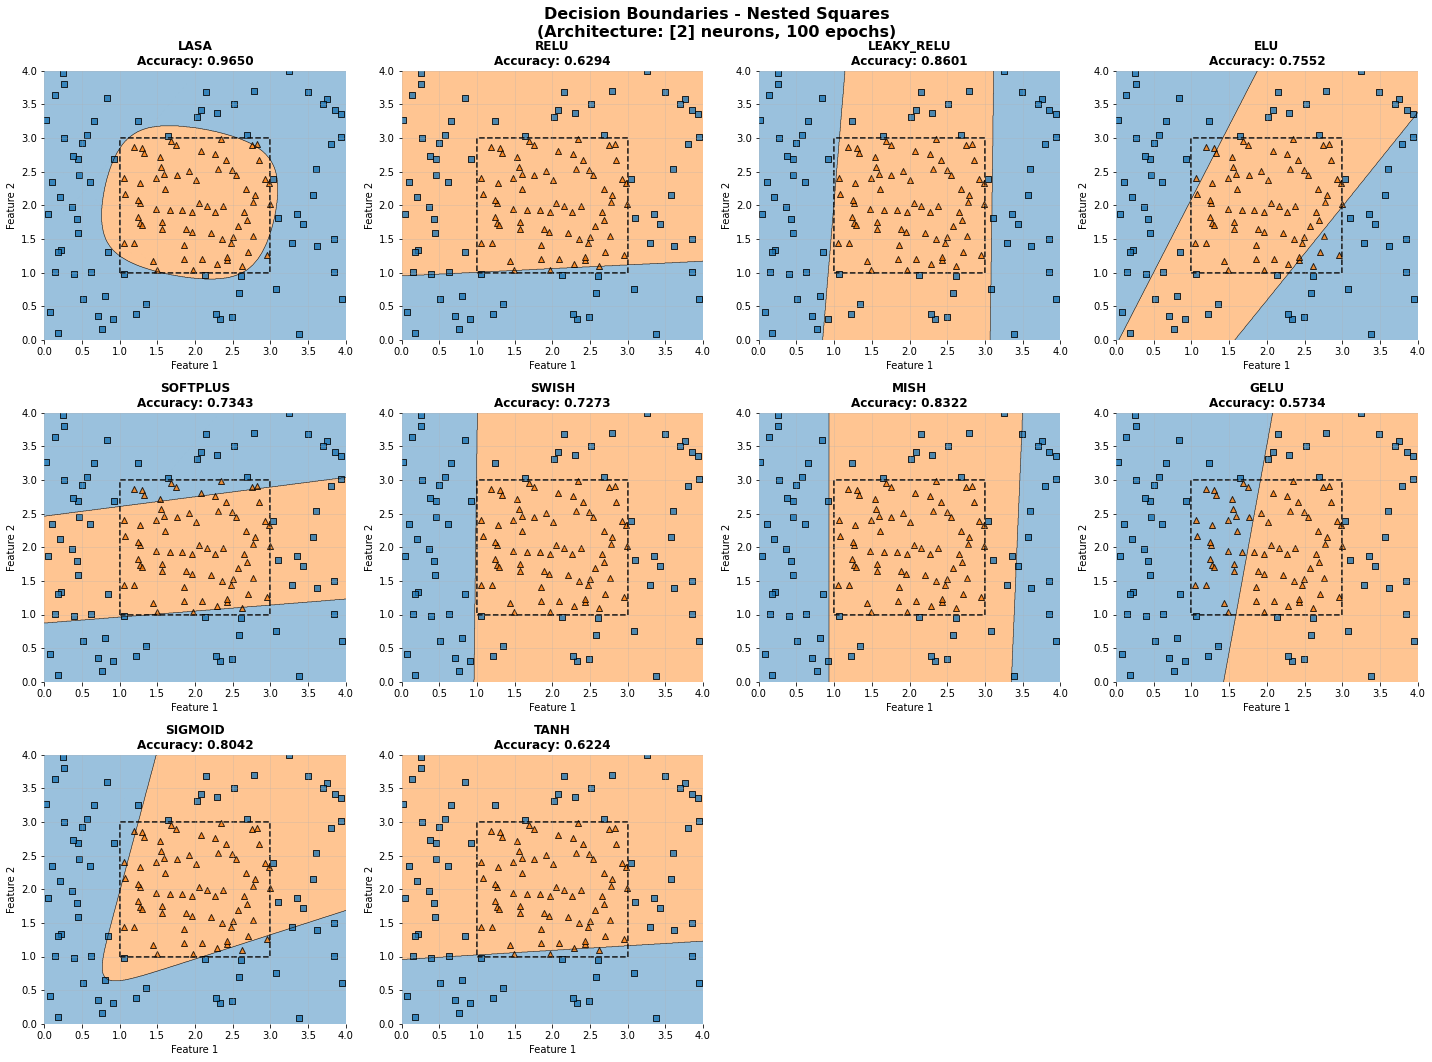

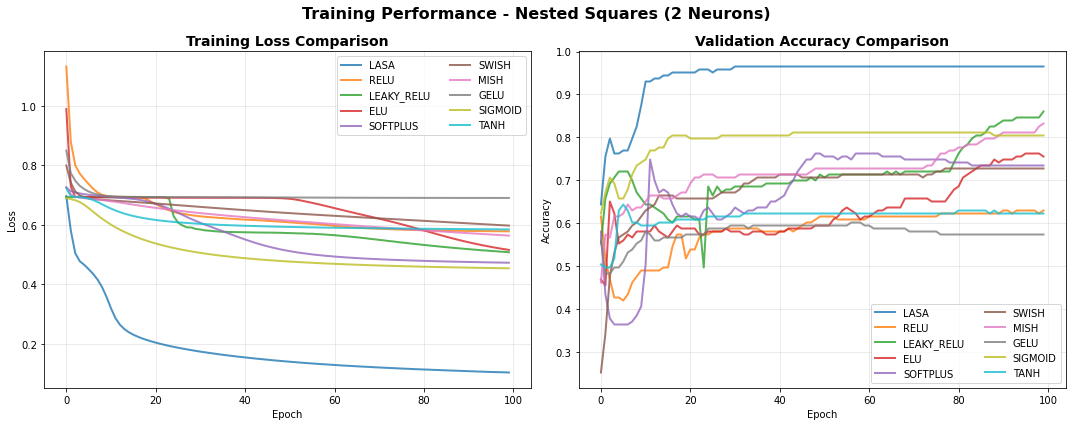


NESTED SQUARES ANALYSIS (2 NEURONS)

Key Challenge:
- Creating a box-like decision boundary requires 4 linear boundaries
- With only 2 neurons, this is extremely challenging for most activations
- LASA can potentially create multiple boundaries per neuron via oscillations

LASA Performance:
  Accuracy: 0.9650
  vs RELU: +33.57%
  vs SIGMOID: +16.08%

Theoretical Insight:
- ReLU with 2 neurons can create at most 2 linear boundaries
- Sigmoid/Tanh with 2 neurons create smooth transitions, not sharp boxes
- LASA with proper frequency can create multiple decision regions per neuron


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from mlxtend.plotting import plot_decision_regions
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# Dataset Generation - Nested Squares Pattern
# ============================================================================

def make_nested_squares(n_samples=750, outer_square_size=4.0, inner_square_size=2.0):
    """Generate nested squares dataset
    
    Creates a pattern where points inside the inner square are class 1,
    and points in the outer region are class 0.
    This requires learning a box-like decision boundary.
    """
    np.random.seed(42)
    
    # Generate random points in the outer square
    X = np.random.rand(n_samples * 2, 2) * outer_square_size  
    
    half_inner_size = inner_square_size / 2.0
    half_outer_size = outer_square_size / 2.0
    
    # Determine which points are inside the inner square
    inside_inner_square = (
        (X[:, 0] > (half_outer_size - half_inner_size)) & 
        (X[:, 0] < (half_outer_size + half_inner_size)) &
        (X[:, 1] > (half_outer_size - half_inner_size)) & 
        (X[:, 1] < (half_outer_size + half_inner_size))
    )
    
    y = np.where(inside_inner_square, 1, 0)  
    
    # Balance the classes
    X_inner = X[inside_inner_square]
    X_outer = X[~inside_inner_square]
    
    n_class_samples = min(len(X_inner), len(X_outer))
    
    X_balanced = np.vstack([X_inner[:n_class_samples], X_outer[:n_class_samples]])
    y_balanced = np.hstack([np.ones(n_class_samples), np.zeros(n_class_samples)])
    
    # Shuffle the data
    shuffle_idx = np.random.permutation(len(y_balanced))
    X_balanced = X_balanced[shuffle_idx]
    y_balanced = y_balanced[shuffle_idx]
    
    return X_balanced, y_balanced.astype(np.int_)


# ============================================================================
# LASA Component
# ============================================================================

class LASAActivation(tf.keras.layers.Layer):
    """Layer-wise Adaptive Sine Activation (LASA) layer"""
    
    def __init__(self, initial_frequency=1.6, **kwargs):
        super().__init__(**kwargs)
        self.initial_frequency = initial_frequency
    
    def build(self, input_shape):
        self.tau = self.add_weight(
            shape=(), 
            initializer=tf.keras.initializers.Constant(self.initial_frequency),
            trainable=True, 
            name='tau'
        )
    
    def call(self, inputs):
        return tf.math.sin(self.tau * inputs)


# ============================================================================
# Custom Activation Layers
# ============================================================================

class MishActivation(tf.keras.layers.Layer):
    """Mish activation: x * tanh(softplus(x))"""
    def call(self, inputs):
        return inputs * tf.math.tanh(tf.math.softplus(inputs))


class SwishActivation(tf.keras.layers.Layer):
    """Swish activation: x * sigmoid(x)"""
    def call(self, inputs):
        return inputs * tf.nn.sigmoid(inputs)


# ============================================================================
# Model Builder for Single Layer with 2 Neurons
# ============================================================================

def create_model(activation_type, hidden_units=[2], initial_frequency=1.6):
    """Create a model with specified activation function and single hidden layer with 2 neurons"""
    
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(2,)))
    
    # Single hidden layer with 2 neurons
    model.add(tf.keras.layers.Dense(hidden_units[0], name='dense_0'))
    
    # Add activation based on type
    if activation_type == 'lasa':
        model.add(LASAActivation(initial_frequency=initial_frequency, name='lasa_0'))
    elif activation_type == 'relu':
        model.add(tf.keras.layers.ReLU(name='relu_0'))
    elif activation_type == 'leaky_relu':
        model.add(tf.keras.layers.LeakyReLU(alpha=0.01, name='leaky_relu_0'))
    elif activation_type == 'elu':
        model.add(tf.keras.layers.ELU(alpha=1.0, name='elu_0'))
    elif activation_type == 'softplus':
        model.add(tf.keras.layers.Activation('softplus', name='softplus_0'))
    elif activation_type == 'swish':
        model.add(SwishActivation(name='swish_0'))
    elif activation_type == 'mish':
        model.add(MishActivation(name='mish_0'))
    elif activation_type == 'gelu':
        model.add(tf.keras.layers.Activation('gelu', name='gelu_0'))
    elif activation_type == 'sine':
        model.add(tf.keras.layers.Activation(tf.math.sin, name='sine_0'))
    elif activation_type == 'sigmoid':
        model.add(tf.keras.layers.Activation('sigmoid', name='sigmoid_0'))
    elif activation_type == 'tanh':
        model.add(tf.keras.layers.Activation('tanh', name='tanh_0'))
    
    # Output layer
    model.add(tf.keras.layers.Dense(1, activation='sigmoid', name='output'))
    
    return model


# ============================================================================
# Universal Trainer
# ============================================================================

class UniversalTrainer:
    """Trainer that works for all activation types"""
    
    def __init__(self, model, activation_type, lr_main=0.001, lr_tau=0.1):
        self.model = model
        self.activation_type = activation_type
        self.loss_fn = tf.keras.losses.BinaryCrossentropy()
        
        # For LASA, use separate optimizers
        if activation_type == 'lasa':
            self.optimizer_main = tf.keras.optimizers.Adam(learning_rate=lr_main)
            self.optimizer_tau = tf.keras.optimizers.Adam(learning_rate=lr_tau)
        else:
            self.optimizer = tf.keras.optimizers.Adam(learning_rate=lr_main)
    
    @tf.function
    def train_step_lasa(self, x_batch, y_batch):
        """Training step for LASA with separate tau optimization"""
        with tf.GradientTape() as tape:
            predictions = self.model(x_batch, training=True)
            y_batch = tf.reshape(y_batch, (-1, 1))
            loss = self.loss_fn(y_batch, predictions)
        
        grads = tape.gradient(loss, self.model.trainable_variables)
        
        tau_vars = [v for v in self.model.trainable_variables if 'tau' in v.name]
        other_vars = [v for v in self.model.trainable_variables if 'tau' not in v.name]
        
        tau_grads = [g for g, v in zip(grads, self.model.trainable_variables) if 'tau' in v.name]
        other_grads = [g for g, v in zip(grads, self.model.trainable_variables) if 'tau' not in v.name]
        
        self.optimizer_tau.apply_gradients(zip(tau_grads, tau_vars))
        self.optimizer_main.apply_gradients(zip(other_grads, other_vars))
        
        return loss
    
    @tf.function
    def train_step_regular(self, x_batch, y_batch):
        """Training step for regular activations"""
        with tf.GradientTape() as tape:
            predictions = self.model(x_batch, training=True)
            y_batch = tf.reshape(y_batch, (-1, 1))
            loss = self.loss_fn(y_batch, predictions)
        
        grads = tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
        
        return loss
    
    def train(self, X_train, y_train, X_test, y_test, epochs=100, batch_size=32, verbose=False):
        """Train the model"""
        history = {'loss': [], 'val_accuracy': []}
        
        for epoch in range(epochs):
            total_loss = 0.0
            num_batches = 0
            
            for i in range(0, len(X_train), batch_size):
                x_batch = X_train[i:i+batch_size]
                y_batch = y_train[i:i+batch_size]
                
                if self.activation_type == 'lasa':
                    batch_loss = self.train_step_lasa(x_batch, y_batch)
                else:
                    batch_loss = self.train_step_regular(x_batch, y_batch)
                
                total_loss += batch_loss.numpy()
                num_batches += 1
            
            avg_loss = total_loss / num_batches
            
            # Evaluation
            predictions = self.model(X_test)
            y_pred = (predictions > 0.5).numpy().astype(int).flatten()
            accuracy = np.mean(y_pred == y_test)
            
            history['loss'].append(avg_loss)
            history['val_accuracy'].append(accuracy)
            
            if verbose and (epoch % 20 == 0 or epoch == epochs - 1):
                print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Val Acc: {accuracy:.4f}")
        
        # Print final tau value for LASA
        if self.activation_type == 'lasa':
            for layer in self.model.layers:
                if 'lasa' in layer.name:
                    print(f"Final tau: {layer.tau.numpy():.4f}")
        
        return history


# ============================================================================
# Visualization Functions
# ============================================================================

def plot_dataset(X, y, title="Nested Squares Dataset", outer_size=4.0, inner_size=2.0):
    """Plot the nested squares dataset"""
    plt.figure(figsize=(10, 8))
    
    # Plot data points
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', 
                        edgecolors='black', linewidth=0.5, alpha=0.8, s=30)
    
    # Draw the squares
    half_inner = inner_size / 2.0
    half_outer = outer_size / 2.0
    
    # Outer square
    outer_rect = plt.Rectangle((0, 0), outer_size, outer_size, 
                              fill=False, edgecolor='gray', linewidth=2, linestyle='--')
    plt.gca().add_patch(outer_rect)
    
    # Inner square
    inner_rect = plt.Rectangle((half_outer - half_inner, half_outer - half_inner), 
                              inner_size, inner_size,
                              fill=False, edgecolor='black', linewidth=2)
    plt.gca().add_patch(inner_rect)
    
    plt.colorbar(scatter, label='Class')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.xlim(-0.2, outer_size + 0.2)
    plt.ylim(-0.2, outer_size + 0.2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_all_decision_boundaries(models, results, X_test, y_test, hidden_units, outer_size=4.0, inner_size=2.0):
    """Plot decision boundaries for all activation functions"""
    
    # Create wrapper for mlxtend
    class ModelWrapper:
        def __init__(self, keras_model):
            self.model = keras_model
        
        def predict(self, X):
            return (self.model(X) > 0.5).numpy().astype(int).flatten()
    
    # Create subplots
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()
    
    activation_names = list(models.keys())
    
    for idx, activation in enumerate(activation_names):
        ax = axes[idx]
        model = models[activation]
        accuracy = results[activation]['accuracy']
        
        # Plot decision regions
        wrapper = ModelWrapper(model)
        plot_decision_regions(X=X_test, y=y_test, clf=wrapper, 
                            ax=ax, legend=0)
        
        # Draw the squares
        half_inner = inner_size / 2.0
        half_outer = outer_size / 2.0
        
        # Inner square (ground truth)
        inner_rect = plt.Rectangle((half_outer - half_inner, half_outer - half_inner), 
                                  inner_size, inner_size,
                                  fill=False, edgecolor='black', linewidth=1.5, linestyle='--')
        ax.add_patch(inner_rect)
        
        # Set title with accuracy
        title = f"{activation.upper()}\nAccuracy: {accuracy:.4f}"
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Feature 1', fontsize=10)
        ax.set_ylabel('Feature 2', fontsize=10)
        ax.set_xlim(0, outer_size)
        ax.set_ylim(0, outer_size)
        ax.grid(True, alpha=0.3)
    
    # Remove extra subplot if any
    if len(activation_names) < len(axes):
        for idx in range(len(activation_names), len(axes)):
            fig.delaxes(axes[idx])
    
    plt.suptitle(f'Decision Boundaries - Nested Squares\n(Architecture: {hidden_units} neurons, 100 epochs)', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_training_curves_comparison(results):
    """Plot training curves for all activations"""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    for activation, data in results.items():
        # Plot loss
        ax1.plot(data['history']['loss'], label=activation.upper(), linewidth=2, alpha=0.8)
        
        # Plot accuracy
        ax2.plot(data['history']['val_accuracy'], label=activation.upper(), linewidth=2, alpha=0.8)
    
    ax1.set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend(loc='best', ncol=2)
    ax1.grid(True, alpha=0.3)
    
    ax2.set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend(loc='best', ncol=2)
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle('Training Performance - Nested Squares (2 Neurons)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


def print_comparison_table(results):
    """Print a formatted comparison table"""
    
    print("\n" + "="*70)
    print("FINAL RESULTS - NESTED SQUARES (SINGLE LAYER, 2 NEURONS)")
    print("="*70)
    print(f"{'Rank':<6} {'Activation':<15} {'Accuracy':<12} {'Final Loss':<12}")
    print("-"*70)
    
    # Sort by accuracy
    sorted_results = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)
    
    for rank, (activation, data) in enumerate(sorted_results, 1):
        print(f"{rank:<6} {activation.upper():<15} {data['accuracy']:<12.4f} {data['final_loss']:<12.4f}")
    
    print("="*70)


# ============================================================================
# Comparison Experiment
# ============================================================================

def run_nested_squares_comparison(hidden_units=[2], initial_frequency=1.6,
                                 n_samples=750, outer_square_size=4.0, 
                                 inner_square_size=2.0, test_size=0.2,
                                 epochs=100, batch_size=32, random_state=42):
    """Compare all activation functions on nested squares with only 2 neurons"""
    
    # Define all activation types to compare
    activation_types = [
        'lasa', 'relu', 'leaky_relu', 'elu', 'softplus', 
        'swish', 'mish', 'gelu', 'sigmoid', 'tanh'
    ]
    
    # Generate dataset
    print("="*70)
    print("ACTIVATION COMPARISON - NESTED SQUARES (2 NEURONS ONLY)")
    print("="*70)
    print("\nExperiment Configuration:")
    print(f"  Architecture: {hidden_units[0]} neurons (single hidden layer)")
    print(f"  Initial tau (LASA): {initial_frequency}")
    print(f"  Outer square: {outer_square_size}x{outer_square_size}")
    print(f"  Inner square: {inner_square_size}x{inner_square_size}")
    print(f"  Epochs: {epochs}")
    print(f"  Batch size: {batch_size}")
    
    print("\nGenerating Nested Squares dataset...")
    X, y = make_nested_squares(n_samples=n_samples, 
                               outer_square_size=outer_square_size,
                               inner_square_size=inner_square_size)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    print(f"\nDataset info:")
    print(f"  Total samples: {len(X)}")
    print(f"  Training samples: {len(X_train)}")
    print(f"  Test samples: {len(X_test)}")
    print(f"  Class balance: {np.sum(y==0)} outer, {np.sum(y==1)} inner")
    print(f"  Challenge: Create box boundary with only 2 neurons!")
    
    # Plot the dataset
    plot_dataset(X, y, outer_size=outer_square_size, inner_size=inner_square_size)
    
    results = {}
    models = {}
    
    print("\nTraining models with different activations...")
    print("="*70)
    
    for activation in activation_types:
        print(f"\n{activation.upper()} activation:")
        print("-"*30)
        
        # Create model
        model = create_model(activation, hidden_units, initial_frequency)
        
        # Print model summary for first activation
        if activation == activation_types[0]:
            print(f"Model architecture:")
            print(f"  Input: 2 features")
            print(f"  Hidden: {hidden_units[0]} neurons with {activation} activation")
            print(f"  Output: 1 neuron with sigmoid")
            print(f"  Total parameters: {model.count_params()}")
            print()
        
        # Train model
        trainer = UniversalTrainer(model, activation, lr_main=0.01, lr_tau=0.1)
        history = trainer.train(X_train, y_train, X_test, y_test, 
                              epochs=epochs, batch_size=batch_size, verbose=False)
        
        # Final evaluation
        predictions = model(X_test)
        y_pred = (predictions > 0.5).numpy().astype(int).flatten()
        final_accuracy = np.mean(y_pred == y_test)
        
        # Store results
        results[activation] = {
            'accuracy': final_accuracy,
            'history': history,
            'final_loss': history['loss'][-1]
        }
        models[activation] = model
        
        print(f"Final Accuracy: {final_accuracy:.4f}")
        print(f"Final Loss: {history['loss'][-1]:.4f}")
    
    return models, results, X, y, X_test, y_test, hidden_units, outer_square_size, inner_square_size


# ============================================================================
# Main Execution
# ============================================================================

if __name__ == "__main__":
    # Clear any existing models
    tf.keras.backend.clear_session()
    
    # Run the nested squares experiment with only 2 neurons
    models, results, X, y, X_test, y_test, hidden_units, outer_size, inner_size = run_nested_squares_comparison(
        hidden_units=[2], 
        initial_frequency=1.6,
        n_samples=750,
        outer_square_size=4.0,
        inner_square_size=2.0,
        epochs=100, 
        batch_size=32
    )
    
    # Print comparison table
    print_comparison_table(results)
    
    # Plot all decision boundaries
    plot_all_decision_boundaries(models, results, X_test, y_test, hidden_units, outer_size, inner_size)
    
    # Plot training curves
    plot_training_curves_comparison(results)
    
    # Analysis
    print("\n" + "="*70)
    print("NESTED SQUARES ANALYSIS (2 NEURONS)")
    print("="*70)
    
    print("\nKey Challenge:")
    print("- Creating a box-like decision boundary requires 4 linear boundaries")
    print("- With only 2 neurons, this is extremely challenging for most activations")
    print("- LASA can potentially create multiple boundaries per neuron via oscillations")
    
    if 'lasa' in results:
        print(f"\nLASA Performance:")
        print(f"  Accuracy: {results['lasa']['accuracy']:.4f}")
        
        # Compare with others
        for act in ['relu', 'sine', 'sigmoid']:
            if act in results:
                diff = results['lasa']['accuracy'] - results[act]['accuracy']
                print(f"  vs {act.upper()}: {'+' if diff > 0 else ''}{diff:.2%}")
    
    print("\nTheoretical Insight:")
    print("- ReLU with 2 neurons can create at most 2 linear boundaries")
    print("- Sigmoid/Tanh with 2 neurons create smooth transitions, not sharp boxes")
    print("- LASA with proper frequency can create multiple decision regions per neuron")